In [81]:
# Importing the dataset and the necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Loading the datset and converying it into a pandas dataframe

In [82]:
import pandas as pd
# Load Iris dataset
df = pd.read_csv('Iris.csv')

# Dislaying the first 10 rows
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


## ii)

In [83]:
df.shape

(150, 6)

- The dataset has 150 rows and 6 columns

In [84]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

- from above we can tell that our data has one categorical data and the other are continous

In [85]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

- Our dataset has no any missing values 

In [86]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [87]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## b)

In [88]:
df.describe(include='all')

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,NaN,50
mean,75.500000,5.843333,3.054000,3.758667,1.198667,NaN
std,43.445368,0.828066,0.433594,1.764420,0.763161,NaN
min,1.000000,4.300000,2.000000,1.000000,0.100000,NaN
25%,38.250000,5.100000,2.800000,1.600000,0.300000,NaN
50%,75.500000,5.800000,3.000000,4.350000,1.300000,NaN
75%,112.750000,6.400000,3.300000,5.100000,1.800000,NaN


## ii)

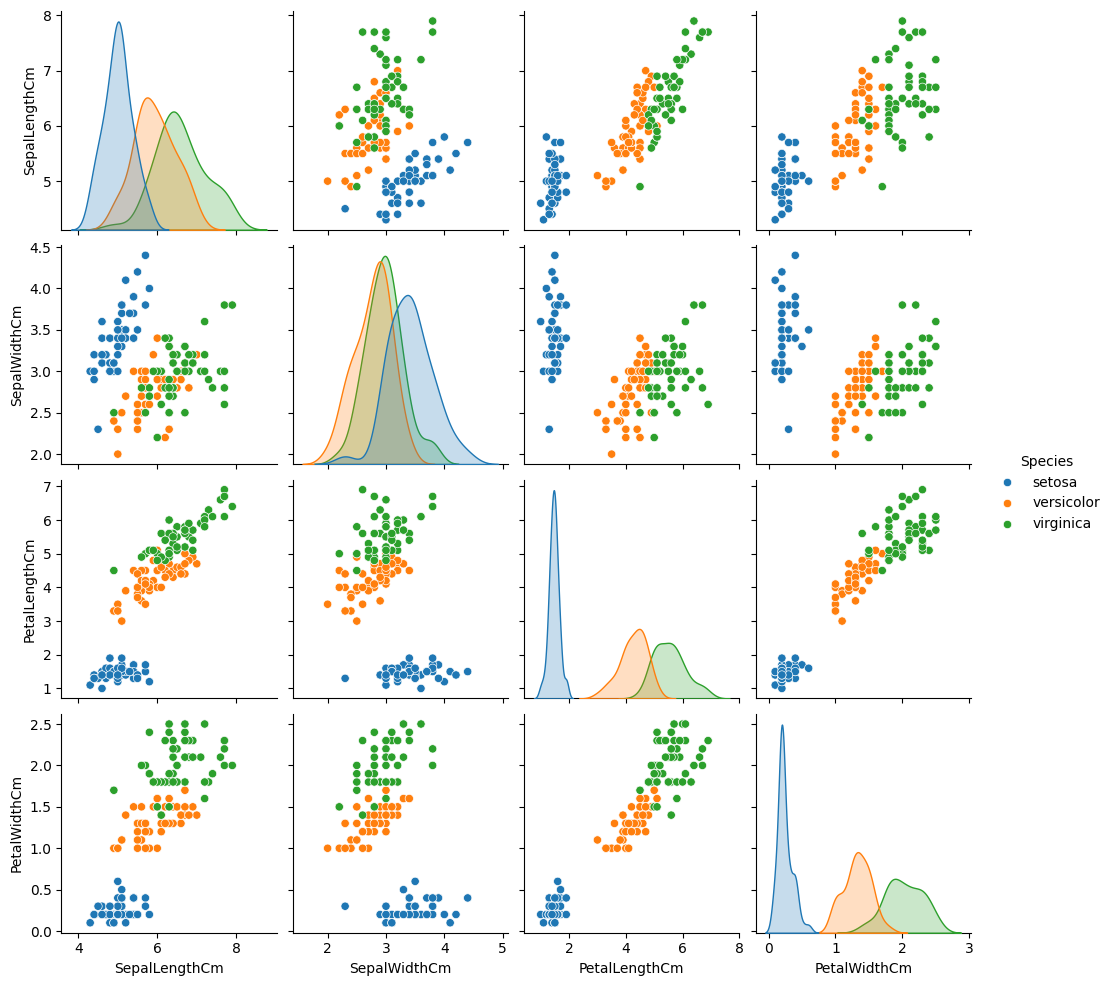

In [89]:
import seaborn as sns   
df['Species'] = iris.target_names[iris.target]
sns.pairplot(df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']], hue='Species')

## iii)

In [90]:
cont_data = df.select_dtypes(include=['float64', 'int64'])
cont_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


In [91]:
cat_data = df.select_dtypes(include=['object'])
cat_data.head()

,Species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


<Axes: >

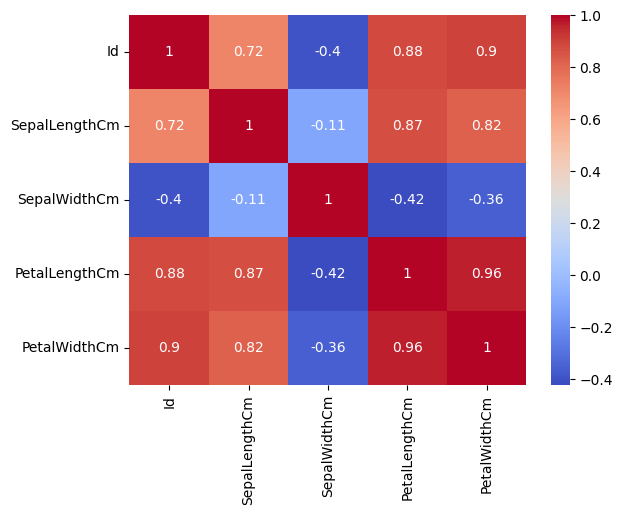

In [92]:
import seaborn as sns
sns.heatmap(cont_data.corr(), annot=True, cmap='coolwarm')

- PetalWidthCm has a strong positive correlation with id
- PetalLengthCm has a strong positive correlation with id

## iv)

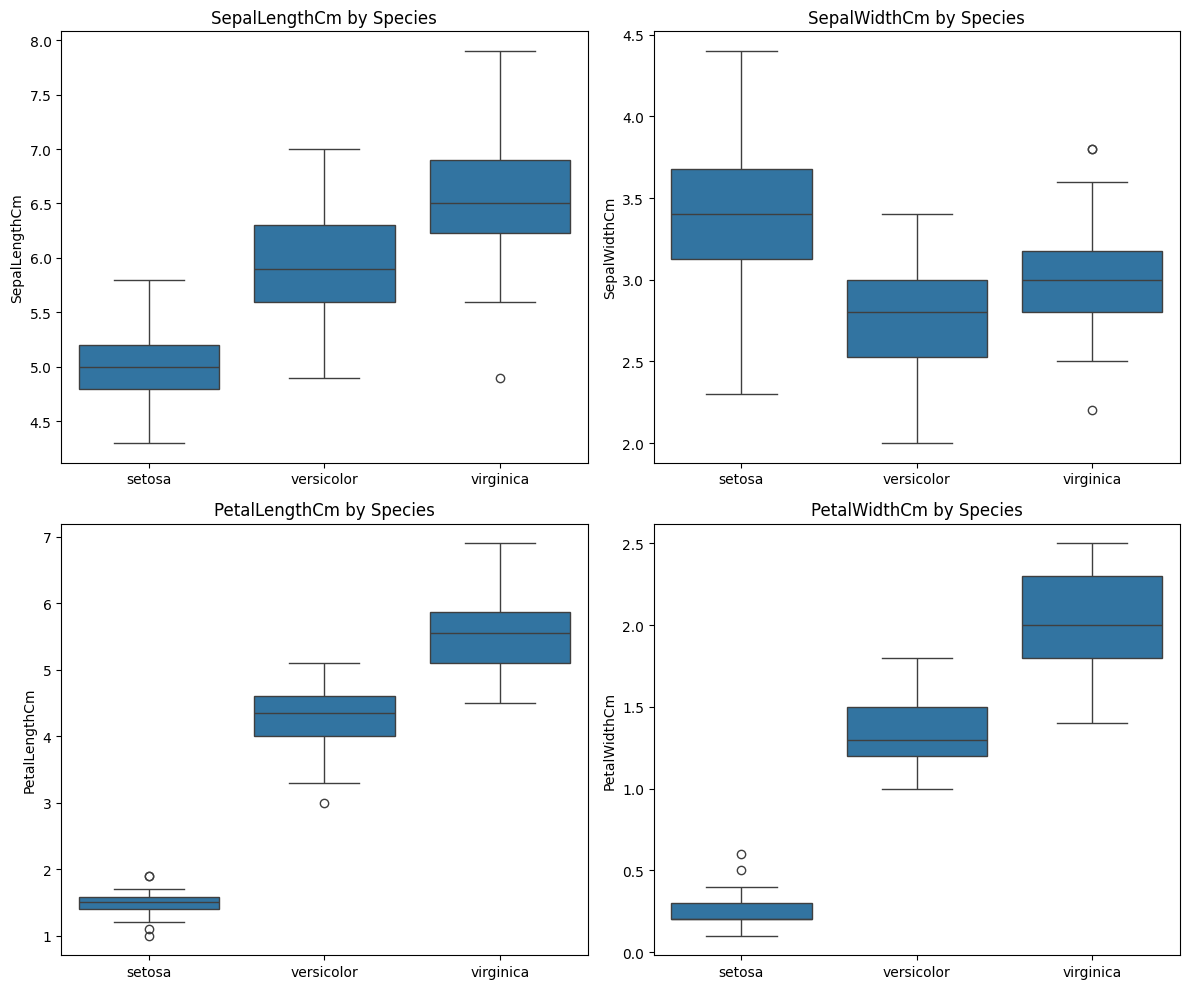

In [93]:
import matplotlib.pyplot as plt
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, feat in zip(axes, features):
    sns.boxplot(x='Species', y=feat, data=df, ax=ax)
    ax.set_title(f'{feat} by Species')
    ax.set_xlabel('')

plt.tight_layout()


## c)

- Encoding our dataset to deal with the categorical values

In [94]:
df =pd.get_dummies(df, drop_first=True, dtype=int)

In [95]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_versicolor,Species_virginica
0,1,5.1,3.5,1.4,0.2,0,0
1,2,4.9,3.0,1.4,0.2,0,0
2,3,4.7,3.2,1.3,0.2,0,0
3,4,4.6,3.1,1.5,0.2,0,0
4,5,5.0,3.6,1.4,0.2,0,0


In [96]:
x = iris.data
y = iris.target
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print("Training samples:", x_train.shape)
print("Testing samples:", y_test.shape)

Training samples: (120, 4)
Testing samples: (30,)


## ii)

## iii)

In [97]:
from sklearn.metrics import accuracy_score
k_values = (3,5,7,9,11)
accuracies = []

for k in k_values:
    
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    
    predictions = model.predict(x_test)
    
    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)
    print(f'k value = {k} and the accuracy is {acc}')

k value = 3 and the accuracy is 1.0
k value = 5 and the accuracy is 1.0
k value = 7 and the accuracy is 0.9666666666666667
k value = 9 and the accuracy is 1.0
k value = 11 and the accuracy is 1.0


## d)

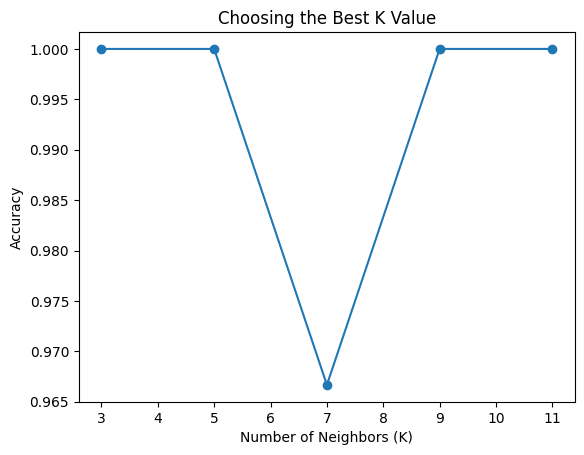

In [98]:
import matplotlib.pyplot as plt
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Choosing the Best K Value")
plt.show()

In [99]:
knn = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

knn.fit(x_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [100]:
predictions = knn.predict(x_test)
cm = confusion_matrix(y_test, predictions)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## iii)

In [101]:
print(classification_report(y_test, predictions, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## iv)

versicolor